In [2]:
# In the last project we have already seen example of the MNIST data set. Here we take a look at Cats and Dogs

import pandas as pd 

PATHIM = "cnd_large//images.csv" 
PATHLB = "cnd_large//labels.csv"

images_data = pd.read_csv(PATHIM, sep=",", index_col=0)
labels_data = pd.read_csv(PATHLB, sep=",", index_col=0)

labels_data = labels_data.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images_data.shape}")
print(f"'labels' size: {labels_data.shape}")

# Number of classes:
print(f"Classes {labels_data["label"].unique()}")

# Get indices for each class, fixed
class0_idx = labels_data[labels_data["label"] == 0].sample(n=1000, random_state=42).index
class1_idx = labels_data[labels_data["label"] == 1].sample(n=1000, random_state=42).index

# Combine indices
selected_idx = class0_idx.union(class1_idx)

# Subset both datasets using the same indices
images_sub = images_data.loc[selected_idx]
labels_sub = labels_data.loc[selected_idx]

# Check sizes
print(f"'images' sub size: {images_sub.shape}")
print(f"'labels' sub size: {labels_sub.shape}")

# Number of classes:
print(f"Classes {labels_sub["label"].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]
'images' sub size: (2000, 4096)
'labels' sub size: (2000, 1)
Classes [0 1]


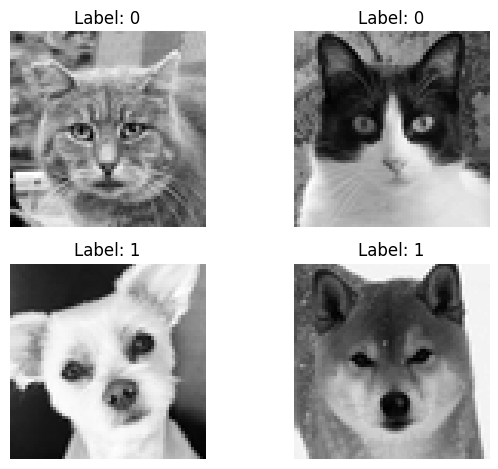

In [4]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images_sub)
labels = np.array(labels_sub).ravel()

#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Fixed train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)




Selected pixels: 1400 / 4096

--- 20 most significant pixels ---
 original_index  row  col     t_stat  p_value_raw  p_value_corrected  selected
           1115   17   27 -15.298915 6.432072e-49       2.634577e-45      True
           1179   18   27 -15.150062 4.687617e-48       9.600239e-45      True
           1119   17   31 -14.966949 5.077169e-47       6.932028e-44      True
           1114   17   26 -14.926293 8.052787e-47       8.246054e-44      True
           1178   18   26 -14.846183 2.414874e-46       1.978265e-43      True
           1252   19   36 -14.759919 6.731456e-46       3.446505e-43      True
           1123   17   35 -14.766630 6.092472e-46       3.446505e-43      True
           1054   16   30 -14.773511 5.925568e-46       3.446505e-43      True
           1188   18   36 -14.737675 9.126557e-46       3.738238e-43      True
           1116   17   28 -14.752027 8.315099e-46       3.738238e-43      True
           1055   16   31 -14.700365 1.459978e-45       5.436428e-

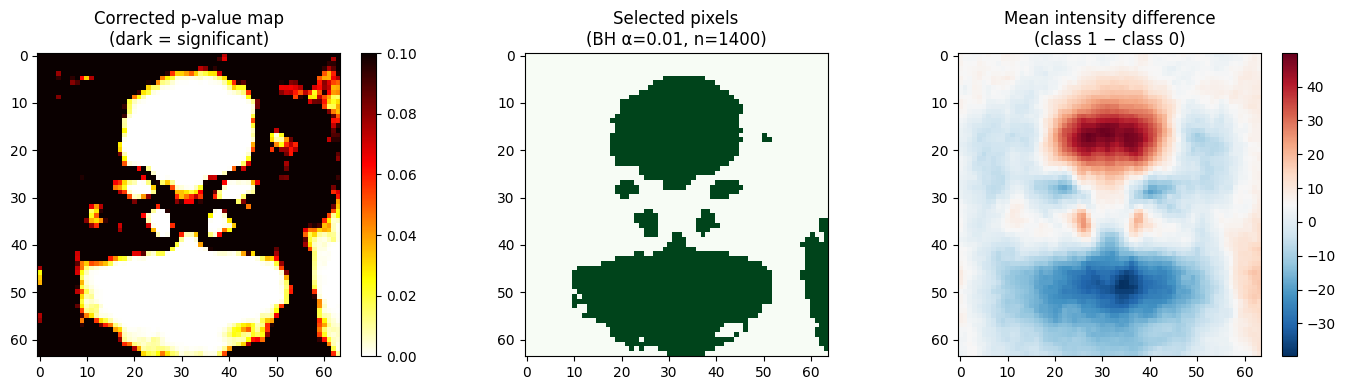

In [6]:
#Multiple testing for feature selection, keep original indices intact
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

X0 = X_train_full[y_train_full == 0]
X1 = X_train_full[y_train_full == 1]

#T-test per pixel
t_stats, p_values = stats.ttest_ind(X0, X1, axis=0, equal_var=False)  # Welch's t-test

#False discovery rate, BH correction
reject, p_corrected, _, _ = multipletests(p_values, alpha=0.01, method="fdr_bh")
print(f"Selected pixels: {reject.sum()} / {len(reject)}")

#P-values
img_size = 64
all_indices = np.arange(X_train_full.shape[1])  # 0 to 4095
results = pd.DataFrame({
    "original_index":    all_indices,
    "row":               all_indices // img_size,
    "col":               all_indices  % img_size,
    "t_stat":            t_stats,
    "p_value_raw":       p_values,
    "p_value_corrected": p_corrected,
    "selected":          reject
}).sort_values("p_value_corrected")

print("\n--- 20 most significant pixels ---")
print(results.head(20).to_string(index=False))
print("\n--- 10 least significant pixels ---")
print(results.tail(10).to_string(index=False))
print("\n--- Selection summary ---")
print(results["selected"].value_counts())

#Visualize
p_map      = p_corrected.reshape(img_size, img_size)
sig_map    = reject.reshape(img_size, img_size)
effect_map = (X1.mean(axis=0) - X0.mean(axis=0)).reshape(img_size, img_size)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(p_map, cmap="hot_r", vmax=0.1)
axes[0].set_title("Corrected p-value map\n(dark = significant)")
plt.colorbar(im0, ax=axes[0])

axes[1].imshow(sig_map, cmap="Greens")
axes[1].set_title(f"Selected pixels\n(BH α=0.01, n={reject.sum()})")

im2 = axes[2].imshow(effect_map, cmap="RdBu_r")
axes[2].set_title("Mean intensity difference\n(class 1 − class 0)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig("pixel_selection.png", dpi=150)

#Reduce features based on p-values
selected_original_indices = all_indices[reject]         # original column positions of selected pixels
X_selected = X_train_full[:, selected_original_indices]
print(f"\nX_train_full shape : {X_train_full.shape}")
print(f"X_selected shape   : {X_selected.shape}  ← reduced feature matrix")


lookup = pd.DataFrame({
    "X_selected_col":  np.arange(len(selected_original_indices)),
    "original_index":  selected_original_indices,
    "row":             selected_original_indices // img_size,
    "col":             selected_original_indices  % img_size
})
print(lookup.head(10).to_string(index=False))

X_selected shape : (1400, 1400)
X_reduced shape  : (1400, 700)  ← after RF pruning


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 384 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 685 out of 700 | elapsed:   10.8s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 700 out of 700 | elapsed:   10.9s finished

[2026-05-09 12:15:20] Features: 1/50 -- score: 0.7167427630504865[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 504 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 684 out of 699 | elapsed:    4.8s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 699 out of 699 | elapsed:    4.9s finished

[2026-05-09 12:15:26] Features: 2/50 -- score: 0.7838415058293856[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Don


X_reduced shape  : (1400, 700)
X_forward shape  : (1400, 50)  ← after forward selection

--- Forward selection lookup (first 10) ---
 X_selected_col  original_index  row  col  X_reduced_col  X_forward_col
             45             544    8   32              9              0
            144             803   12   35             27              1
            209             980   15   20             42              2
            255            1064   16   40             72              3
            256            1065   16   41             73              4
            259            1068   16   44             74              5
            265            1110   17   22             77              6
            270            1115   17   27             82              7
            282            1127   17   39             93              8
            284            1129   17   41             94              9


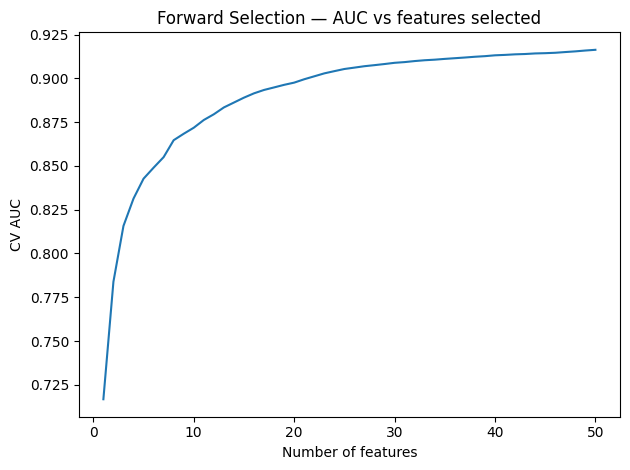

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# RF is scale-invariant so no leakage risk, doesnt need scaler
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    threshold="median"
)
X_reduced = selector.fit_transform(X_selected, y_train_full)
print(f"X_selected shape : {X_selected.shape}")
print(f"X_reduced shape  : {X_reduced.shape}  ← after RF pruning")

rf_mask = selector.get_support()
lookup_reduced = lookup[rf_mask].copy()
lookup_reduced["X_reduced_col"] = np.arange(rf_mask.sum())
lookup_reduced = lookup_reduced.reset_index(drop=True)

# mlxtend's SFS runs CV internally. Wrap in a Pipeline to refit
#scaler on each inner fold to prevent leakage
estimator_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(solver="saga", max_iter=1000, tol=1e-3))
])

sfs = SequentialFeatureSelector(
    estimator=estimator_pipeline,
    k_features=50,
    forward=True,
    floating=False,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=2
)
sfs.fit(X_reduced, y_train_full)

X_forward = sfs.transform(X_reduced)
print(f"\nX_reduced shape  : {X_reduced.shape}")
print(f"X_forward shape  : {X_forward.shape}  ← after forward selection")

forward_mask = list(sfs.k_feature_idx_)
lookup_forward = lookup_reduced.iloc[forward_mask].copy()
lookup_forward["X_forward_col"] = np.arange(len(forward_mask))
lookup_forward = lookup_forward.reset_index(drop=True)

#Update lookup to track original indices
forward_mask = list(sfs.k_feature_idx_)  # column indices within X_reduced

lookup_forward = lookup_reduced.iloc[forward_mask].copy()
lookup_forward["X_forward_col"] = np.arange(len(forward_mask))
lookup_forward = lookup_forward.reset_index(drop=True)
print("\n--- Forward selection lookup (first 10) ---")
print(lookup_forward.head(10).to_string(index=False))

#AUC vs features plot
k_scores = [sfs.subsets_[k]["avg_score"] for k in sorted(sfs.subsets_.keys())]
plt.plot(sorted(sfs.subsets_.keys()), k_scores)
plt.xlabel("Number of features")
plt.ylabel("CV AUC")
plt.title("Forward Selection — AUC vs features selected")
plt.tight_layout()
plt.savefig("forward_selection.png", dpi=150)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

#Fit scaler on full training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)

#Slice training data through the same chain as X_forward
X_train_forward = X_train_scaled[:, selected_original_indices][:, rf_mask][:, forward_mask]

#Slice test data through the same chain
X_test_scaled  = scaler.transform(X_test)
X_test_forward = X_test_scaled[:, selected_original_indices][:, rf_mask][:, forward_mask]


classifiers = {
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5, metric="euclidean", weights="distance"),
    "Logistic Regression": LogisticRegression(solver="lbfgs", max_iter=1000)
}

#Train on scaled, reduced training data
for name, clf in classifiers.items():
    clf.fit(X_train_forward, y_train_full)
    print(f"{name} fitted successfully")

#Evaluate on scaled, reduced test data
for name, clf in classifiers.items():
    y_pred  = clf.predict(X_test_forward)
    y_proba = clf.predict_proba(X_test_forward)[:, 1]
    print(f"\n{name}  AUC: {roc_auc_score(y_test, y_proba):.3f}")
    print(confusion_matrix(y_test, y_pred))
    

Random Forest fitted successfully
KNN fitted successfully
Logistic Regression fitted successfully

Random Forest  AUC: 0.893
[[237  63]
 [ 50 250]]

KNN  AUC: 0.828
[[263  37]
 [121 179]]

Logistic Regression  AUC: 0.828
[[227  73]
 [ 76 224]]


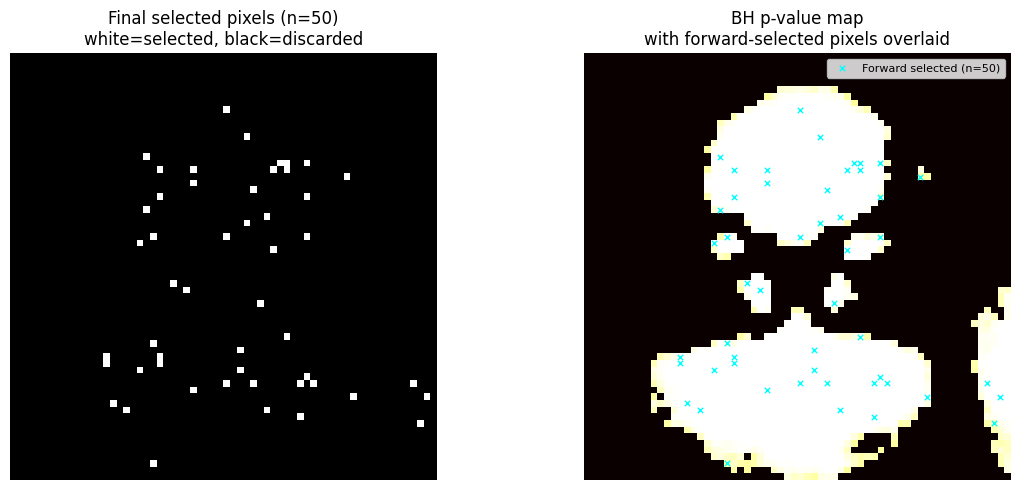

In [12]:
#Which of the 4096 pixels were finally selected
final_pixel_map = np.zeros(img_size * img_size, dtype=int)
final_original_indices = lookup_forward["original_index"].values
final_pixel_map[final_original_indices] = 1
final_pixel_map = final_pixel_map.reshape(img_size, img_size)


#Heat map, selected_original_indices tells us where in the 4096 space those p-values live
p_map_full = np.ones(img_size * img_size)  # default: 1.0 (non-significant)
p_map_full[selected_original_indices] = p_corrected[reject]  # only the BH-selected p-values
p_map_full = p_map_full.reshape(img_size, img_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Black and white map of final selected pixels
axes[0].imshow(final_pixel_map, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Final selected pixels (n={len(final_original_indices)})\nwhite=selected, black=discarded")
axes[0].axis("off")

#BH significance heatmap with selected pixels overlaid
axes[1].imshow(p_map_full, cmap="hot_r", vmin=0, vmax=0.1)

rows = final_original_indices // img_size
cols = final_original_indices  % img_size
axes[1].scatter(cols, rows, c="cyan", s=15, marker="x", linewidths=1,
                label=f"Forward selected (n={len(final_original_indices)})")
axes[1].set_title("BH p-value map\nwith forward-selected pixels overlaid")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("selected_pixels_map.png", dpi=150)
plt.show()

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]
'images' sub size: (2000, 4096)
'labels' sub size: (2000, 1)
Classes [0 1]

RUN 1 / 5
BH selected: 1366 / 4096 pixels
RF pruning selected: 683 / 1366 pixels
Forward selection selected: 50 pixels
Final original indices: [ 329  549  930  933  994 1047 1110 1115 1129 1184 1240 1252 1309 1311
 1324 1381 1426 1491 1493 1503 1772 1813 1823 1887 1960 2023 2278 2328
 2331 2342 2457 2468 2469 2715 2905 2967 2988 3035 3116 3172 3175 3177
 3180 3182 3244 3311 3390 3430 3775 3838]

RUN 2 / 5
BH selected: 1365 / 4096 pixels
RF pruning selected: 683 / 1365 pixels
Forward selection selected: 50 pixels
Final original indices: [ 924  990 1055 1110 1121 1177 1178 1190 1193 1234 1240 1253 1297 1313
 1381 1388 1426 1493 1564 1626 1772 1811 1814 2202 2331 2469 2654 2832
 2848 2857 2860 2966 3025 3033 3046 3110 3169 3172 3173 3180 3219 3300
 3351 3359 3389 3424 3430 3580 3677 3837]

RUN 3 / 5
BH selected: 1443 / 4096 pixels
RF pruning sele

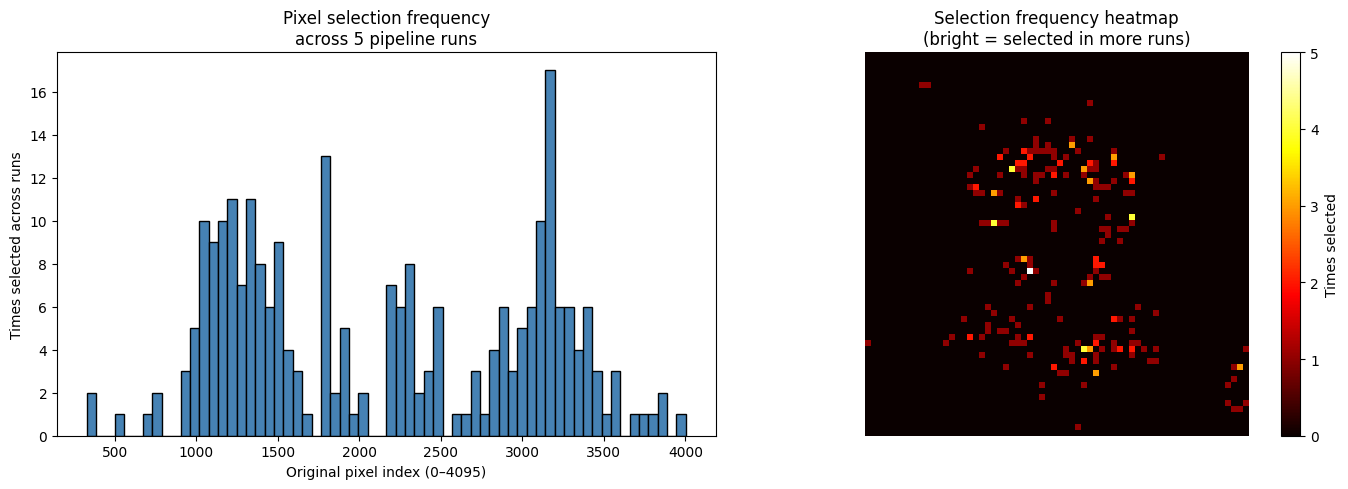


--- Most consistently selected pixels ---
 original_index  row  col  times_selected  pct_runs
           2331   36   27               5     100.0
           1240   19   24               4      80.0
           1813   28   21               4      80.0
           1772   27   44               4      80.0
           3172   49   36               4      80.0
           1381   21   37               3      60.0
           2469   38   37               3      60.0
           2202   34   26               3      60.0
           1324   20   44               3      60.0
            994   15   34               3      60.0
           1252   19   36               3      60.0
           1129   17   41               3      60.0
           1493   23   21               3      60.0
           3173   49   37               3      60.0
           3390   52   62               3      60.0
           3430   53   38               3      60.0
           1426   22   18               2      40.0
           2214   34 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

PATHIM = "cnd_large//images.csv" 
PATHLB = "cnd_large//labels.csv"

images_data = pd.read_csv(PATHIM, sep=",", index_col=0)
labels_data = pd.read_csv(PATHLB, sep=",", index_col=0)

labels_data = labels_data.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images_data.shape}")
print(f"'labels' size: {labels_data.shape}")

# Number of classes:
print(f"Classes {labels_data["label"].unique()}")

# Get indices for each class
class0_idx = labels_data[labels_data["label"] == 0].sample(n=1000, random_state=42).index
class1_idx = labels_data[labels_data["label"] == 1].sample(n=1000, random_state=42).index

# Combine indices
selected_idx = class0_idx.union(class1_idx)

# Subset both datasets using the same indices
images_sub = images_data.loc[selected_idx]
labels_sub = labels_data.loc[selected_idx]

# Check sizes
print(f"'images' sub size: {images_sub.shape}")
print(f"'labels' sub size: {labels_sub.shape}")

# Number of classes:
print(f"Classes {labels_sub["label"].unique()}")

X = np.array(images_sub)
y = np.array(labels_sub).ravel()

img_size  = 64
n_runs    = 5      # number of times to rerun the pipeline
all_selected_pixels = []  # collect selected original indices from each run

for run in range(n_runs):
    print(f"\n{'='*50}")
    print(f"RUN {run + 1} / {n_runs}")
    print(f"{'='*50}")

    X_train, X_test_run, y_train, y_test_run = train_test_split(
        X, y, test_size=0.3, random_state=None, stratify=y  
    )

    X0 = X_train[y_train == 0]
    X1 = X_train[y_train == 1]
    _, p_values = stats.ttest_ind(X0, X1, axis=0, equal_var=False)
    reject, p_corrected, _, _ = multipletests(p_values, alpha=0.01, method="fdr_bh")
    print(f"BH selected: {reject.sum()} / {X_train.shape[1]} pixels")

    selected_original_indices_run = np.where(reject)[0]
    X_selected_run = X_train[:, selected_original_indices_run]

    selector = SelectFromModel(
        RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=None),
        threshold="median"
    )
    X_reduced_run = selector.fit_transform(X_selected_run, y_train)
    rf_mask_run   = selector.get_support()
    print(f"RF pruning selected: {rf_mask_run.sum()} / {X_selected_run.shape[1]} pixels")

    estimator_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(solver="saga", max_iter=1000, tol=1e-3))
    ])

    sfs = SequentialFeatureSelector(
        estimator=estimator_pipeline,
        n_features_to_select=50,
        direction="forward",
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )
    sfs.fit(X_reduced_run, y_train)
    forward_mask_run = sfs.get_support()
    print(f"Forward selection selected: {forward_mask_run.sum()} pixels")

    original_indices_after_rf      = selected_original_indices_run[rf_mask_run]
    original_indices_after_forward = original_indices_after_rf[forward_mask_run]
    all_selected_pixels.append(original_indices_after_forward)
    print(f"Final original indices: {original_indices_after_forward}")

print(f"\nDone. Collected selections from {n_runs} runs.")

#Histogram of selected pixels across all the runs
all_pixels_flat = np.concatenate(all_selected_pixels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_pixels_flat, bins=img_size, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Original pixel index (0–4095)")
axes[0].set_ylabel("Times selected across runs")
axes[0].set_title(f"Pixel selection frequency\nacross {n_runs} pipeline runs")

#Frequency heatmap on the 64x64 image grid
freq_map = np.zeros(img_size * img_size, dtype=int)
for idx in all_pixels_flat:
    freq_map[idx] += 1
freq_map = freq_map.reshape(img_size, img_size)

im = axes[1].imshow(freq_map, cmap="hot", vmin=0, vmax=n_runs)
axes[1].set_title(f"Selection frequency heatmap\n(bright = selected in more runs)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="Times selected")

plt.tight_layout()
plt.savefig("pixel_stability.png", dpi=150)
plt.show()

#Summary table, most consistently selected pixels
unique, counts = np.unique(all_pixels_flat, return_counts=True)
stability = pd.DataFrame({
    "original_index": unique,
    "row":            unique // img_size,
    "col":            unique  % img_size,
    "times_selected": counts,
    "pct_runs":       (counts / n_runs * 100).round(1)
}).sort_values("times_selected", ascending=False)

print("\n--- Most consistently selected pixels ---")
print(stability.head(20).to_string(index=False))

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]
'images' sub size: (2000, 4096)
'labels' sub size: (2000, 1)
Classes [0 1]
Selected pixels: 1327 / 4096

--- 20 most significant pixels ---
 original_index  row  col    t_stat  p_value_raw  p_value_corrected  selected
           1189   18   37 16.176477 5.016040e-54       2.054570e-50      True
           1253   19   37 15.811397 6.845986e-52       1.402058e-48      True
           1188   18   36 15.668334 4.678925e-51       4.791220e-48      True
           1125   17   37 15.673200 4.520965e-51       4.791220e-48      True
           1190   18   38 15.553731 2.356161e-50       1.930167e-47      True
           1252   19   36 15.507838 3.891206e-50       2.656396e-47      True
           1114   17   26 15.438952 1.021569e-49       5.977638e-47      True
           1115   17   27 15.410961 1.493392e-49       7.646167e-47      True
           1119   17   31 15.393658 1.981463e-49       9.017859e-47      True
           

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 236 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 664 out of 664 | elapsed:   10.7s finished

[2026-05-09 19:00:22] Features: 1/50 -- score: 0.7280814942127547[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 504 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 663 out of 663 | elapsed:    5.1s finished

[2026-05-09 19:00:28] Features: 2/50 -- score: 0.8002829402146023[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 276 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 647 out of 662 | elapsed:    5.9s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 662 out of 662 | 


X_reduced shape  : (1400, 664)
X_forward shape  : (1400, 50)  ← after forward selection

--- Forward selection lookup (first 10) ---
 X_selected_col  original_index  row  col  X_reduced_col  X_forward_col
            174             978   15   18             41              0
            184             988   15   28             46              1
            198            1002   15   42             53              2
            201            1042   16   18             55              3
            209            1050   16   26             60              4
            212            1053   16   29             63              5
            219            1060   16   36             69              6
            232            1110   17   22             75              7
            237            1115   17   27             80              8
            261            1176   18   24             99              9
Random Forest fitted successfully
KNN fitted successfully
Logistic Regress

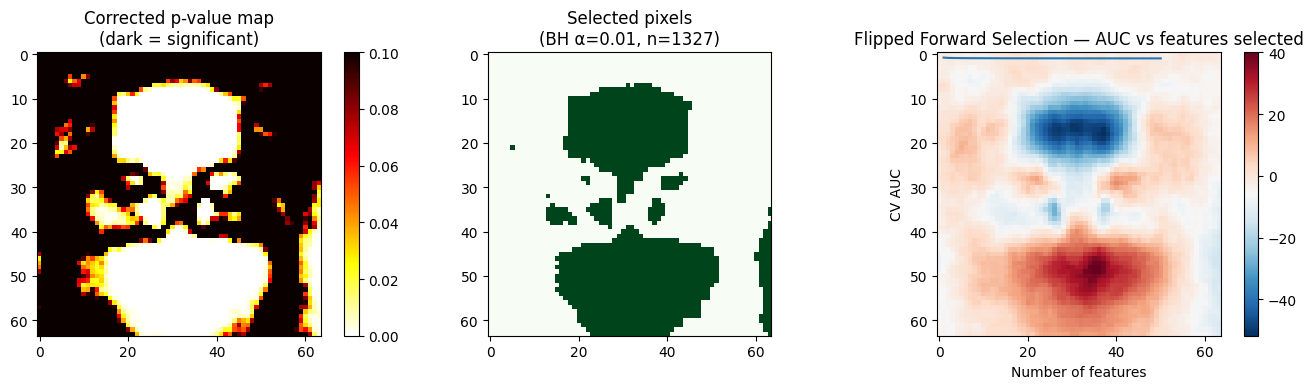

In [5]:
##Original pipeline on flipped images

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

PATHIM = "cnd_large//images.csv" 
PATHLB = "cnd_large//labels.csv"

images_data = pd.read_csv(PATHIM, sep=",", index_col=0)
labels_data = pd.read_csv(PATHLB, sep=",", index_col=0)

labels_data = labels_data.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images_data.shape}")
print(f"'labels' size: {labels_data.shape}")

# Number of classes:
print(f"Classes {labels_data["label"].unique()}")

# Get indices for each class
class0_idx = labels_data[labels_data["label"] == 0].sample(n=1000, random_state=42).index
class1_idx = labels_data[labels_data["label"] == 1].sample(n=1000, random_state=42).index

# Combine indices
selected_idx = class0_idx.union(class1_idx)

# Subset both datasets using the same indices
images_sub = images_data.loc[selected_idx]
labels_sub = labels_data.loc[selected_idx]

# Check sizes
print(f"'images' sub size: {images_sub.shape}")
print(f"'labels' sub size: {labels_sub.shape}")

# Number of classes:
print(f"Classes {labels_sub["label"].unique()}")

X = np.flipud(np.array(images_sub))
y = np.array(labels_sub).ravel()

# Fixed train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X0 = X_train_full[y_train_full == 0]
X1 = X_train_full[y_train_full == 1]

t_stats, p_values = stats.ttest_ind(X0, X1, axis=0, equal_var=False)  # Welch's t-test

reject, p_corrected, _, _ = multipletests(p_values, alpha=0.01, method="fdr_bh")
print(f"Selected pixels: {reject.sum()} / {len(reject)}")

img_size = 64
all_indices = np.arange(X_train_full.shape[1])  # 0 to 4095
results = pd.DataFrame({
    "original_index":    all_indices,
    "row":               all_indices // img_size,
    "col":               all_indices  % img_size,
    "t_stat":            t_stats,
    "p_value_raw":       p_values,
    "p_value_corrected": p_corrected,
    "selected":          reject
}).sort_values("p_value_corrected")

print("\n--- 20 most significant pixels ---")
print(results.head(20).to_string(index=False))
print("\n--- 10 least significant pixels ---")
print(results.tail(10).to_string(index=False))
print("\n--- Selection summary ---")
print(results["selected"].value_counts())

p_map      = p_corrected.reshape(img_size, img_size)
sig_map    = reject.reshape(img_size, img_size)
effect_map = (X1.mean(axis=0) - X0.mean(axis=0)).reshape(img_size, img_size)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(p_map, cmap="hot_r", vmax=0.1)
axes[0].set_title("Corrected p-value map\n(dark = significant)")
plt.colorbar(im0, ax=axes[0])

axes[1].imshow(sig_map, cmap="Greens")
axes[1].set_title(f"Selected pixels\n(BH α=0.01, n={reject.sum()})")

im2 = axes[2].imshow(effect_map, cmap="RdBu_r")
axes[2].set_title("Mean intensity difference\n(class 1 − class 0)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig("pixel_selection_flipped.png", dpi=150)

selected_original_indices = all_indices[reject]         # original column positions of selected pixels
X_selected = X_train_full[:, selected_original_indices]
print(f"\nX_train_full shape : {X_train_full.shape}")
print(f"X_selected shape   : {X_selected.shape}  ← reduced feature matrix")


lookup = pd.DataFrame({
    "X_selected_col":  np.arange(len(selected_original_indices)),
    "original_index":  selected_original_indices,
    "row":             selected_original_indices // img_size,
    "col":             selected_original_indices  % img_size
})
print(lookup.head(10).to_string(index=False))

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression


selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    threshold="median"
)
X_reduced = selector.fit_transform(X_selected, y_train_full)
print(f"X_selected shape : {X_selected.shape}")
print(f"X_reduced shape  : {X_reduced.shape}  ← after RF pruning")

rf_mask = selector.get_support()
lookup_reduced = lookup[rf_mask].copy()
lookup_reduced["X_reduced_col"] = np.arange(rf_mask.sum())
lookup_reduced = lookup_reduced.reset_index(drop=True)

estimator_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(solver="saga", max_iter=1000, tol=1e-3))
])

sfs = SequentialFeatureSelector(
    estimator=estimator_pipeline,
    k_features=50,
    forward=True,
    floating=False,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=2
)
sfs.fit(X_reduced, y_train_full)

X_forward = sfs.transform(X_reduced)
print(f"\nX_reduced shape  : {X_reduced.shape}")
print(f"X_forward shape  : {X_forward.shape}  ← after forward selection")

forward_mask = list(sfs.k_feature_idx_)
lookup_forward = lookup_reduced.iloc[forward_mask].copy()
lookup_forward["X_forward_col"] = np.arange(len(forward_mask))
lookup_forward = lookup_forward.reset_index(drop=True)


forward_mask = list(sfs.k_feature_idx_)  # column indices within X_reduced

lookup_forward = lookup_reduced.iloc[forward_mask].copy()
lookup_forward["X_forward_col"] = np.arange(len(forward_mask))
lookup_forward = lookup_forward.reset_index(drop=True)
print("\n--- Forward selection lookup (first 10) ---")
print(lookup_forward.head(10).to_string(index=False))


k_scores = [sfs.subsets_[k]["avg_score"] for k in sorted(sfs.subsets_.keys())]
plt.plot(sorted(sfs.subsets_.keys()), k_scores)
plt.xlabel("Number of features")
plt.ylabel("CV AUC")
plt.title("Flipped Forward Selection — AUC vs features selected")
plt.tight_layout()


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)

X_train_forward = X_train_scaled[:, selected_original_indices][:, rf_mask][:, forward_mask]


X_test_scaled  = scaler.transform(X_test)
X_test_forward = X_test_scaled[:, selected_original_indices][:, rf_mask][:, forward_mask]


classifiers = {
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5, metric="euclidean", weights="distance"),
    "Logistic Regression": LogisticRegression(solver="lbfgs", max_iter=1000)
}


for name, clf in classifiers.items():
    clf.fit(X_train_forward, y_train_full)
    print(f"{name} fitted successfully")

for name, clf in classifiers.items():
    y_pred  = clf.predict(X_test_forward)
    y_proba = clf.predict_proba(X_test_forward)[:, 1]
    print(f"\n{name}  AUC: {roc_auc_score(y_test, y_proba):.3f}")
    print(confusion_matrix(y_test, y_pred))

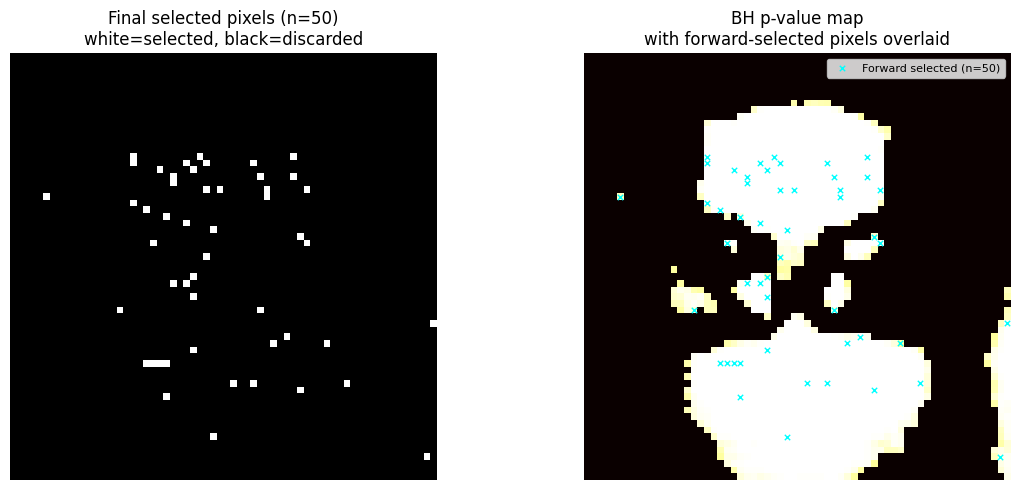

In [6]:

final_pixel_map = np.zeros(img_size * img_size, dtype=int)
final_original_indices = lookup_forward["original_index"].values
final_pixel_map[final_original_indices] = 1
final_pixel_map = final_pixel_map.reshape(img_size, img_size)


p_map_full = np.ones(img_size * img_size) 
p_map_full[selected_original_indices] = p_corrected[reject]  # only the BH-selected p-values
p_map_full = p_map_full.reshape(img_size, img_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].imshow(final_pixel_map, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Final selected pixels (n={len(final_original_indices)})\nwhite=selected, black=discarded")
axes[0].axis("off")

axes[1].imshow(p_map_full, cmap="hot_r", vmin=0, vmax=0.1)

rows = final_original_indices // img_size
cols = final_original_indices  % img_size
axes[1].scatter(cols, rows, c="cyan", s=15, marker="x", linewidths=1,
                label=f"Forward selected (n={len(final_original_indices)})")
axes[1].set_title("BH p-value map\nwith forward-selected pixels overlaid")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("selected_pixels_map_flipped.png", dpi=150)
plt.show()